In [5]:
import pandas as pd
dta = pd.read_csv('../data/complaints.csv')
dta.shape


(11522175, 18)

In [6]:
#lowercase column names and replace spaces with underscores
dta.columns = dta.columns.str.lower().str.replace(' ', '_')
dta.head(2)

,date_received,product,sub-product,issue,sub-issue,consumer_complaint_narrative,company_public_response,company,state,zip_code,tags,consumer_consent_provided?,submitted_via,date_sent_to_company,company_response_to_consumer,timely_response?,consumer_disputed?,complaint_id
0,2020-07-06,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,FL,346XX,NaN,Other,Web,2020-07-06,Closed with explanation,Yes,NaN,3730948
1,2025-10-14,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information is missing that should be on the r...,NaN,NaN,"EQUIFAX, INC.",TX,75062,NaN,NaN,Web,2025-10-14,In progress,Yes,NaN,16558024


In [7]:
dta.head(2)
#convert date received to datetime
dta['date_received'] = pd.to_datetime(dta['date_received'])
#convert date_recieved to date only
dta['date_received'] = dta['date_received'].dt.date
dta['date_received'].head(2)


0    2020-07-06
1    2025-10-14
Name: date_received, dtype: object

In [8]:
#keep only the lat 3 years of data
dta = dta[dta['date_received'] >= pd.to_datetime('2024-11-01').date()]
print(dta.shape)
dta.head(2)


(4869958, 18)


,date_received,product,sub-product,issue,sub-issue,consumer_complaint_narrative,company_public_response,company,state,zip_code,tags,consumer_consent_provided?,submitted_via,date_sent_to_company,company_response_to_consumer,timely_response?,consumer_disputed?,complaint_id
1,2025-10-14,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information is missing that should be on the r...,NaN,NaN,"EQUIFAX, INC.",TX,75062,NaN,NaN,Web,2025-10-14,In progress,Yes,NaN,16558024
2,2025-10-10,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,"EQUIFAX, INC.",GA,30341,NaN,NaN,Web,2025-10-10,In progress,Yes,NaN,16507707


In [9]:
dta = dta.loc[dta.company.isin(['CAPITAL ONE FINANCIAL CORPORATION',
                          'JPMORGAN CHASE & CO.',
                          "Block, Inc.",
                          "WELLS FARGO & COMPANY",
                          "BANK OF AMERICA, NATIONAL ASSOCIATION",
                          "CITIBANK, N.A.",
                          "Early Warning Services, LLC",
                          "NAVY FEDERAL CREDIT UNION",
                          "SYNCHRONY FINANCIAL",
                          "AMERICAN EXPRESS COMPANY",
                          "DISCOVER BANK",
                          "Paypal Holdings, Inc",
                          "U.S. BANCORP",
                          "Chime Financial Inc",
                          "ALLY FINANCIAL INC."]), :]

In [10]:
dta.company.value_counts()

company
Block, Inc.                              45616
CAPITAL ONE FINANCIAL CORPORATION        30517
Early Warning Services, LLC              23719
JPMORGAN CHASE & CO.                     21474
NAVY FEDERAL CREDIT UNION                17514
CITIBANK, N.A.                           16936
WELLS FARGO & COMPANY                    16860
BANK OF AMERICA, NATIONAL ASSOCIATION    16483
SYNCHRONY FINANCIAL                      11609
AMERICAN EXPRESS COMPANY                  9465
DISCOVER BANK                             8230
Paypal Holdings, Inc                      5864
Chime Financial Inc                       5599
ALLY FINANCIAL INC.                       5095
U.S. BANCORP                              4734
Name: count, dtype: int64

In [11]:
#count null values in each column
print(dta.shape)
dta.isnull().sum()

(239715, 18)


date_received                        0
product                              0
sub-product                          0
issue                                0
sub-issue                        73456
consumer_complaint_narrative    105864
company_public_response         160277
company                              0
state                             1237
zip_code                             0
tags                            211765
consumer_consent_provided?       36372
submitted_via                        0
date_sent_to_company                 0
company_response_to_consumer         0
timely_response?                     0
consumer_disputed?              239715
complaint_id                         0
dtype: int64

In [12]:
dta.head(2)
w_narr = dta.loc[dta.consumer_complaint_narrative.notnull(), :]
print(w_narr.shape)

(133851, 18)


In [16]:
w_narr['narr_length'] = w_narr.consumer_complaint_narrative.str.len()
w_narr.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
#drop narrative gt 4930 characters
w_narr = w_narr.loc[w_narr.narr_length <= 4930, :]
print(w_narr.shape)

C:\Users\whdgu\AppData\Local\Temp\ipykernel_11984\3828107313.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  w_narr['narr_length'] = w_narr.consumer_complaint_narrative.str.len()


(132512, 19)


In [17]:
#Product/subproduct value counts
w_narr[['product', 'sub-product']].value_counts()
#products / subproducts with less than 1%  complaints
product_counts = w_narr[['product', 'sub-product']].value_counts()
#filter out products with less than 2% complaints
product_counts = product_counts[product_counts <= product_counts.sum() * 0.02]
rare_products = product_counts.index.tolist()
rare_products


[('Checking or savings account', 'Other banking product or service'),
 ('Checking or savings account', 'Savings account'),
 ('Vehicle loan or lease', 'Loan'),
 ('Money transfer, virtual currency, or money service', 'Virtual currency'),
 ('Prepaid card', 'General-purpose prepaid card'),
 ('Debt collection', 'I do not know'),
 ('Mortgage', 'Conventional home mortgage'),
 ('Money transfer, virtual currency, or money service',
  'International money transfer'),
 ('Credit reporting or other personal consumer reports',
  'Other personal consumer report'),
 ('Checking or savings account', 'CD (Certificate of Deposit)'),
 ('Prepaid card', 'Gift card'),
 ('Debt collection', 'Auto debt'),
 ('Prepaid card', 'Government benefit card'),
 ('Debt collection', 'Other debt'),
 ('Money transfer, virtual currency, or money service',
  "Money order, traveler's check or cashier's check"),
 ('Mortgage', 'FHA mortgage'),
 ('Payday loan, title loan, personal loan, or advance loan',
  'Installment loan'),
 ('M

In [18]:
#remove rare products from w_narr
for product, subproduct in rare_products:
    w_narr = w_narr.loc[~((w_narr.product == product) & (w_narr['sub-product'] == subproduct)), :]
print(w_narr.shape)


(132512, 19)


In [19]:
#check if gpu is available
import torch
print(torch.cuda.is_available())
# !pip3 install torch torchvision --index-url https://download.pytorch.org/whl/cu129 --user

# import torch
# print(torch.cuda.is_available())
#install transformers that is gpu compatible
!pip install transformers 


True
Defaulting to user installation because normal site-packages is not writeable


In [20]:
#get embedding model from huggingface
from transformers import AutoTokenizer, AutoModel
#load models on gpu if available
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/all-miniLM-L6-v2")
model = AutoModel.from_pretrained("sentence-transformers/all-miniLM-L6-v2").to(device)
model = model.to(device)

#check model device
next(model.parameters()).device

C:\Users\whdgu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device(type='cuda', index=0)

In [21]:


def embed_text(text):
    #tokenize text
    inputs = tokenizer(text, return_tensors='pt', padding=True, truncation=True).to(device)
    #get model output
    with torch.no_grad():
        outputs = model(**inputs)
    #mean pooling
    embeddings = outputs.last_hidden_state.mean(dim=1)
    return embeddings.cpu().numpy()
#embed all narratives
import numpy as np
embeddings = []
batch_size = 32
for i in range(0, len(w_narr), batch_size):
    print(f"Processing batch {i//batch_size + 1}")
    batch_texts = w_narr['consumer_complaint_narrative'].iloc[i:i+batch_size].tolist()
    batch_embeddings = embed_text(batch_texts)
    embeddings.append(batch_embeddings)
embeddings = np.vstack(embeddings)
print(embeddings.shape)
#save embeddings to pickle file with complaint ids, product, subproduct, company
embeddings_dict = {
    'complaint_id': w_narr['complaint_id'].tolist(),
    'product': w_narr['product'].tolist(),
    'sub-product': w_narr['sub-product'].tolist(),
    'company': w_narr['company'].tolist(),
    'narrative': w_narr['consumer_complaint_narrative'].tolist(),
    'embeddings': embeddings
}
#write to pickle file
import pickle
with open('../data/complaint_embeddings.pkl', 'wb') as f:
    pickle.dump(embeddings_dict, f)
    












Processing batch 1
Processing batch 2
Processing batch 3
Processing batch 4
Processing batch 5
Processing batch 6
Processing batch 7
Processing batch 8
Processing batch 9
Processing batch 10
Processing batch 11
Processing batch 12
Processing batch 13
Processing batch 14
Processing batch 15
Processing batch 16
Processing batch 17
Processing batch 18
Processing batch 19
Processing batch 20
Processing batch 21
Processing batch 22
Processing batch 23
Processing batch 24
Processing batch 25
Processing batch 26
Processing batch 27
Processing batch 28
Processing batch 29
Processing batch 30
Processing batch 31
Processing batch 32
Processing batch 33
Processing batch 34
Processing batch 35
Processing batch 36
Processing batch 37
Processing batch 38
Processing batch 39
Processing batch 40
Processing batch 41
Processing batch 42
Processing batch 43
Processing batch 44
Processing batch 45
Processing batch 46
Processing batch 47
Processing batch 48
Processing batch 49
Processing batch 50
Processin

In [33]:
#add complaint_id, date_received, company, and product, subproduct, narrative to embeddings dataframe
embeddings_df = pd.DataFrame(embeddings)
embeddings_df['complaint_id'] = w_narr['complaint_id'].values
embeddings_df['date_received'] = w_narr['date_received'].values
embeddings_df['company'] = w_narr['company'].values
embeddings_df['product'] = w_narr['product'].values
#embeddings_df['sub_product'] = w_narr['sub_product'].values
embeddings_df['consumer_complaint_narrative'] = w_narr['consumer_complaint_narrative'].values
embeddings_df.head(2)
#save embedding to pickle file
embeddings_df.to_pickle('../data/complaint_embeddings.pkl')


In [ ]:
#company value counts
w_narr.company.value_counts()

In [ ]:
#run cluster analysis using dbscan
from sklearn.cluster import HDBSCAN
#run with multiple eps values

eps_values = [1.0, 1.5, 2.0]
summary = pd.DataFrame()
for eps in eps_values:
    clusterer = HDBSCAN(min_cluster_size=50, metric='cosine')
    cluster_labels = clusterer.fit_predict(embeddings)
    silhouette = silhouette_score(embeddings, cluster_labels)
    n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
    n_noise = list(cluster_labels).count(-1)
    temp_summary = pd.DataFrame({'eps': [eps],
                                 'n_clusters': [n_clusters],
                                 'n_noise': [n_noise],
                                 'silhouette_score': [silhouette]})
    summary = pd.concat([summary, temp_summary], ignore_index=True)

print(summary)

#write to csv
summary.to_csv('../data/cluster_summary.csv', index=False)  


MemoryError: Unable to allocate 133. GiB for an array with shape (133851, 133851) and data type float64

In [36]:
from sklearn.utils import resample


N_SAMPLES = 25000 

if len(embeddings) > N_SAMPLES:
    embeddings_subset = resample(embeddings, n_samples=N_SAMPLES, random_state=442)
else:
    embeddings_subset = embeddings

Threshold: 0.75, Number of clusters: 15513, Silhouette Score: 0.3081322908401489
Threshold: 1, Number of clusters: 15005, Silhouette Score: 0.30340686440467834
Threshold: 2.0, Number of clusters: 9919, Silhouette Score: 0.2682563364505768
Threshold: 3.0, Number of clusters: 4443, Silhouette Score: 0.2374361902475357
Threshold: 4.0, Number of clusters: 1893, Silhouette Score: 0.19751682877540588
Threshold: 4.5, Number of clusters: 1322, Silhouette Score: 0.18377871811389923
Threshold: 5.0, Number of clusters: 971, Silhouette Score: 0.170464426279068
Threshold: 5.5, Number of clusters: 733, Silhouette Score: 0.16051815450191498
Threshold: 6.0, Number of clusters: 577, Silhouette Score: 0.15454599261283875
Threshold: 10, Number of clusters: 168, Silhouette Score: 0.15616942942142487
Threshold: 15, Number of clusters: 73, Silhouette Score: 0.17900876700878143
Threshold: 20, Number of clusters: 44, Silhouette Score: 0.22786793112754822
Threshold: 25, Number of clusters: 28, Silhouette Score

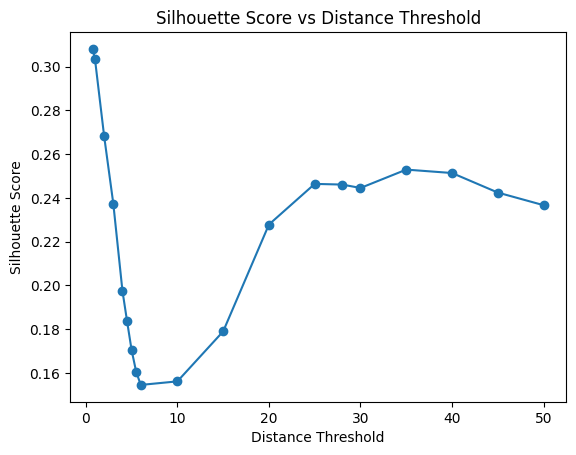

Best Threshold: 0.75


In [37]:
#cluster embeddings using agglomerative clustering
from sklearn.cluster import AgglomerativeClustering
#try different thresholds for clustering and see how many clusters are formed, get silhouette score
from sklearn.metrics import silhouette_score    
thresholds = [.75, 1, 2.0, 3.0,  4.0, 4.5, 5.0, 5.5, 6.0, 10, 15, 20, 25,28,30, 35,40,45,50]
silhouette_scores = pd.DataFrame()
for thresh in thresholds:
    clustering = AgglomerativeClustering(n_clusters=None, distance_threshold=thresh)
    cluster_labels = clustering.fit_predict(embeddings_subset)
    n_clusters = len(set(cluster_labels))
    if n_clusters > 1 and n_clusters < len(embeddings_subset):
        sil_score = silhouette_score(embeddings_subset, cluster_labels)
        sil_score_dict = {'threshold': thresh, 'n_clusters': n_clusters, 'silhouette_score': sil_score}
        sil_score_df = pd.DataFrame([sil_score_dict])
        silhouette_scores = pd.concat([silhouette_scores, sil_score_df], ignore_index=True)

    else:
        sil_score = None
    print(f"Threshold: {thresh}, Number of clusters: {n_clusters}, Silhouette Score: {sil_score}")
#plot silhouette scores
import matplotlib.pyplot as plt
plt.plot(silhouette_scores['threshold'], silhouette_scores['silhouette_score'], marker='o')
plt.xlabel('Distance Threshold')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs Distance Threshold')
plt.show()
# write to csv
silhouette_scores.to_csv('../data/silhouette_scores.csv', index=False)
#get the best threshold based on silhouette score
best_thresh = silhouette_scores.loc[silhouette_scores['silhouette_score'].idxmax(), 'threshold']
print(f"Best Threshold: {best_thresh}")



Cluster subset based on best threshold and then assign all other points to a cluster        

In [46]:
clustering = AgglomerativeClustering(n_clusters=None, distance_threshold=25)
cluster_labels = clustering.fit_predict(embeddings_subset)


In [47]:
#for all embeedings not in subset assign cluster labels based on nearest neighbor in subset
from sklearn.neighbors import NearestNeighbors
nn = NearestNeighbors(n_neighbors=1)
nn.fit(embeddings_subset)
distances, indices = nn.kneighbors(embeddings)
#assign cluster labels from subset to all embeddings
embeddings_df['agglomerative_cluster'] = cluster_labels[indices.flatten()]



In [52]:
#save embeddings with cluster labels to pickle file
embeddings_df.to_pickle('../data/complaint_embeddings_with_clusters.pkl')

In [48]:
embeddings_df.head(2)

,0,1,2,3,4,5,6,7,8,9,...,380,381,382,383,complaint_id,date_received,company,product,consumer_complaint_narrative,agglomerative_cluster
0,-0.370672,-0.297977,0.118031,0.151081,0.284094,-0.118132,0.145074,-0.163338,-0.204628,-0.348756,...,0.212616,-0.059139,0.534717,-0.120117,16179108,2025-09-25,WELLS FARGO & COMPANY,Credit reporting or other personal consumer re...,THESE 3 COMPANIES ARE ON MY CREDIT REPORT AND ...,24
1,-0.111187,-0.089718,0.415655,0.017798,0.136114,-0.181542,0.113605,-0.134354,-0.011274,-0.133676,...,0.269920,-0.069039,0.081852,-0.046670,15305109,2025-08-15,CAPITAL ONE FINANCIAL CORPORATION,Credit reporting or other personal consumer re...,"On XX/XX/scrub>, 2025 I received a text saying...",6


In [ ]:
#set up huggingface transformers model for text generation
# pip install huggingface_hub
# hf auth login # get a read token from hf.co/settings/tokens
import os
from huggingface_hub import InferenceClient

client = InferenceClient()

completion = client.chat.completions.create(
    model="openai/gpt-oss-120b",
    messages=[
        {
            "role": "user",
            "content": "How many 'G's in 'huggingface'?"
        }
    ],
)

print(completion.choices[0].message)

ChatCompletionOutputMessage(role='assistant', content='The word **“huggingface”** contains **3** occurrences of the letter **g** (all lowercase).', reasoning='The user asks: "How many \'G\'s in \'huggingface\'?" They likely mean count the letter \'G\' (case-sensitive?). The word \'huggingface\' contains letters: h u g g i n g f a c e. Lowercase g appears 3 times. There\'s no uppercase G. So answer: 3.', tool_call_id=None, tool_calls=None)
